# Sales Data Visualization
This project analyzes a sales dataset using Python. The objective is to create meaningful visualizations to identify sales trends, compare business performance, and generate actionable insights.

## Import Libraries

In [8]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")

## Load Dataset

In [9]:
df = pd.read_csv("Datasets/sales_data.csv")

df.head()

,Product_ID,Sale_Date,Sales_Rep,Region,Sales_Amount,Quantity_Sold,Product_Category,Unit_Cost,Unit_Price,Customer_Type,Discount,Payment_Method,Sales_Channel,Region_and_Sales_Rep
0,1052,2023-02-03,Bob,North,5053.97,18,Furniture,152.75,267.22,Returning,0.09,Cash,Online,North-Bob
1,1093,2023-04-21,Bob,West,4384.02,17,Furniture,3816.39,4209.44,Returning,0.11,Cash,Retail,West-Bob
2,1015,2023-09-21,David,South,4631.23,30,Food,261.56,371.40,Returning,0.20,Bank Transfer,Retail,South-David
3,1072,2023-08-24,Bob,South,2167.94,39,Clothing,4330.03,4467.75,New,0.02,Credit Card,Retail,South-Bob
4,1061,2023-03-24,Charlie,East,3750.20,13,Electronics,637.37,692.71,New,0.08,Credit Card,Online,East-Charlie


## Understand the Dataset

In [61]:
# 1. Dataset Size
df.shape

(1000, 16)

In [63]:
# 2. Data Types and missing values
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   Product_ID            1000 non-null   int64         
 1   Sale_Date             1000 non-null   datetime64[ns]
 2   Sales_Rep             1000 non-null   object        
 3   Region                1000 non-null   object        
 4   Sales_Amount          1000 non-null   float64       
 5   Quantity_Sold         1000 non-null   int64         
 6   Product_Category      1000 non-null   object        
 7   Unit_Cost             1000 non-null   float64       
 8   Unit_Price            1000 non-null   float64       
 9   Customer_Type         1000 non-null   object        
 10  Discount              1000 non-null   float64       
 11  Payment_Method        1000 non-null   object        
 12  Sales_Channel         1000 non-null   object        
 13  Region_and_Sales_Re

In [64]:
# 3. Statistics
df.describe()

,Product_ID,Sale_Date,Sales_Amount,Quantity_Sold,Unit_Cost,Unit_Price,Discount,Month_Number
count,1000.000000,1000,1000.000000,1000.000000,1000.000000,1000.000000,1000.00000,1000.00000
mean,1050.128000,2023-07-02 17:42:43.199999744,5019.265230,25.355000,2475.304550,2728.440120,0.15239,6.50600
min,1001.000000,2023-01-01 00:00:00,100.120000,1.000000,60.280000,167.120000,0.00000,1.00000
25%,1024.000000,2023-03-30 00:00:00,2550.297500,13.000000,1238.380000,1509.085000,0.08000,3.00000
50%,1051.000000,2023-06-30 12:00:00,5019.300000,25.000000,2467.235000,2696.400000,0.15000,6.00000
75%,1075.000000,2023-10-12 00:00:00,7507.445000,38.000000,3702.865000,3957.970000,0.23000,10.00000
max,1100.000000,2024-01-01 00:00:00,9989.040000,49.000000,4995.300000,5442.150000,0.30000,12.00000
std,29.573505,NaN,2846.790126,14.159006,1417.872546,1419.399839,0.08720,3.54154


In [13]:
df.isnull().sum()

Product_ID              0
Sale_Date               0
Sales_Rep               0
Region                  0
Sales_Amount            0
Quantity_Sold           0
Product_Category        0
Unit_Cost               0
Unit_Price              0
Customer_Type           0
Discount                0
Payment_Method          0
Sales_Channel           0
Region_and_Sales_Rep    0
dtype: int64

## Visualization 1: Total Sales by Product Category (Bar chart)

In [14]:
category_sales = df.groupby("Product_Category")["Sales_Amount"].sum()

category_sales

Product_Category
Clothing       1313474.36
Electronics    1243499.64
Food           1201773.54
Furniture      1260517.69
Name: Sales_Amount, dtype: float64

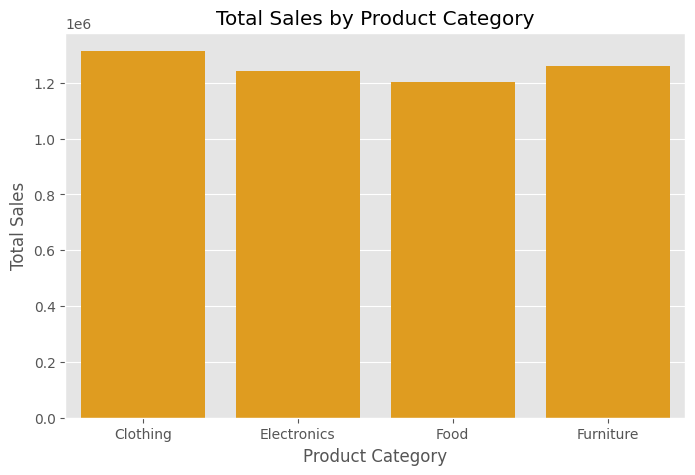

In [127]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    color="orange"
)

plt.title("Total Sales by Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")

plt.savefig("images/category_sales.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- Clothing has the highest total sales among all product categories.
- Food has the lowest total sales.
- The sales across all product categories are relatively balanced, with only small differences between them.
- No single product category dominates the overall sales, indicating a fairly even sales distribution.

## Visualization 2: Total Sales by Region (Bar chart)

In [15]:
region_sales = df.groupby("Region")["Sales_Amount"].sum()

region_sales

Region
East     1259792.93
North    1369612.51
South    1154250.86
West     1235608.93
Name: Sales_Amount, dtype: float64

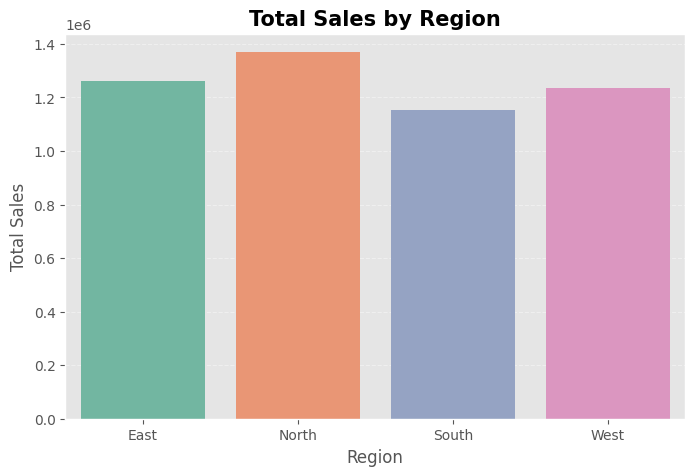

In [32]:
plt.figure(figsize=(8,5))

sns.barplot(
    x=region_sales.index,
    y=region_sales.values,
    hue=region_sales.index,
    palette="Set2",
    legend=False
)

plt.title("Total Sales by Region", fontsize=15, fontweight="bold")
plt.xlabel("Region", fontsize=12)
plt.ylabel("Total Sales", fontsize=12)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.savefig("images/region_sales.png", dpi=300, bbox_inches="tight")

plt.show()

### Observation

- North region generated the highest total sales.
- South region recorded the lowest total sales.
- East and West regions have similar sales performance.
- The sales difference between regions is moderate, indicating relatively balanced regional performance.

## Visualization 3: Sales by Sales Representative (Line chart)

In [33]:
rep_sales = df.groupby("Sales_Rep")["Sales_Amount"].sum()

rep_sales

Sales_Rep
Alice       965541.77
Bob        1080990.63
Charlie     860811.48
David      1141737.36
Eve         970183.99
Name: Sales_Amount, dtype: float64

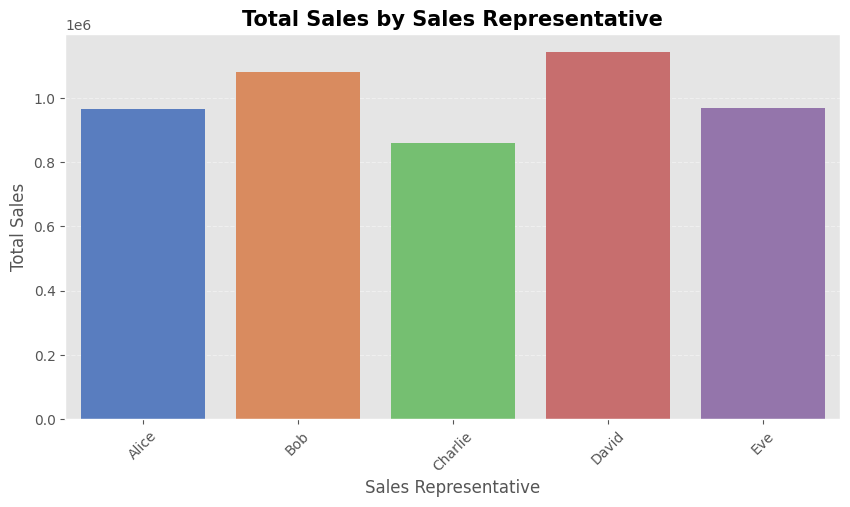

In [34]:
plt.figure(figsize=(10,5))

sns.barplot(
    x=rep_sales.index,
    y=rep_sales.values,
    hue=rep_sales.index,
    palette="muted",
    legend=False
)

plt.title("Total Sales by Sales Representative", fontsize=15, fontweight="bold")
plt.xlabel("Sales Representative")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(axis="y", linestyle="--", alpha=0.4)

plt.savefig("images/sales_rep.png", dpi=300, bbox_inches="tight")

plt.show()

## Observation
- David achieved the highest total sales among all sales representatives.
- Charlie recorded the lowest total sales.
- Bob was the second-highest performer, while Alice and Eve had similar sales.
- Overall, sales performance varied across representatives.

## Business Insight

Recognize the top-performing sales representative and provide additional support or training to improve the performance of lower-performing representatives.

## Visualization 3: Monthly Sales Trend

In [44]:
# Step 1: Convert Sale_Date to Date
df["Sale_Date"] = pd.to_datetime(df["Sale_Date"])

In [43]:
# Step 2: Create a Month Column
df["Month"] = df["Sale_Date"].dt.month_name()

df[["Sale_Date", "Month"]].head()

,Sale_Date,Month
0,2023-02-03,February
1,2023-04-21,April
2,2023-09-21,September
3,2023-08-24,August
4,2023-03-24,March


In [45]:
df["Sale_Date"].dt.year #Returns the year.

0      2023
1      2023
2      2023
3      2023
4      2023
       ... 
995    2023
996    2023
997    2023
998    2023
999    2023
Name: Sale_Date, Length: 1000, dtype: int32

In [46]:
df["Sale_Date"].dt.month #Returns the month number.

0       2
1       4
2       9
3       8
4       3
       ..
995     4
996     9
997     4
998    12
999     8
Name: Sale_Date, Length: 1000, dtype: int32

In [47]:
df["Sale_Date"].dt.month_name() #Returns the month name

0       February
1          April
2      September
3         August
4          March
         ...    
995        April
996    September
997        April
998     December
999       August
Name: Sale_Date, Length: 1000, dtype: object

In [48]:
df["Sale_Date"].dt.day #Returns the day of the month.

0       3
1      21
2      21
3      24
4      24
       ..
995    15
996     7
997    27
998    20
999    16
Name: Sale_Date, Length: 1000, dtype: int32

In [120]:
# Step 3: Calculate Monthly Sales
monthly_sales = (
    df.groupby("Month")["Sales_Amount"].sum()
)
monthly_sales # DISPLAYS IN ALPHABETICAL ORDER, NOT IN CALENDER ORDER

Month
April        438992.61
August       443171.28
December     392643.58
February     368919.36
January      495420.37
July         374242.88
June         418458.34
March        402638.77
May          389078.76
November     467482.90
October      460378.78
September    367837.60
Name: Sales_Amount, dtype: float64

In [121]:
#Grouping by the month number.
df["Month_Number"] = df["Sale_Date"].dt.month

monthly_sales = (
    df.groupby("Month_Number")["Sales_Amount"]
      .sum()
)

monthly_sales

Month_Number
1     495420.37
2     368919.36
3     402638.77
4     438992.61
5     389078.76
6     418458.34
7     374242.88
8     443171.28
9     367837.60
10    460378.78
11    467482.90
12    392643.58
Name: Sales_Amount, dtype: float64

In [55]:
# convert the numbers back into names only for displaying.
import calendar

monthly_sales.index = [calendar.month_name[i] for i in monthly_sales.index]

monthly_sales

January      495420.37
February     368919.36
March        402638.77
April        438992.61
May          389078.76
June         418458.34
July         374242.88
August       443171.28
September    367837.60
October      460378.78
November     467482.90
December     392643.58
Name: Sales_Amount, dtype: float64

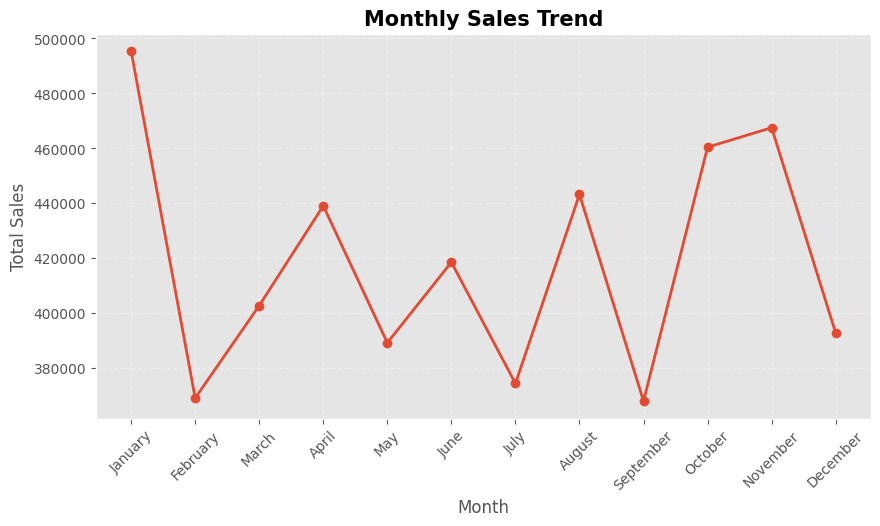

In [59]:
plt.figure(figsize=(10,5))

plt.plot(
    monthly_sales.index,
    monthly_sales.values,
    marker="o",
    linewidth=2
)

plt.title("Monthly Sales Trend", fontsize=15, fontweight="bold")
plt.xlabel("Month")
plt.ylabel("Total Sales")

plt.xticks(rotation=45)

plt.grid(True, linestyle="--", alpha=0.4)

plt.savefig("images/monthly_sales_trend.png", dpi=300, bbox_inches="tight")

    plt.show()

## Observation
- January recorded the highest total sales, while September had the lowest total sales.
- The sales trend fluctuates throughout the year rather than remaining consistent, indicating periods of both growth and decline.
- Sales increased noticeably during January, October, and November, whereas February, July, and September showed comparatively lower sales.
- The fluctuating pattern suggests that sales may be influenced by factors such as seasonal demand, promotional activities, customer purchasing behavior, or market conditions. Further analysis is recommended to identify the reasons behind these variations.

## Business Insight
The company should analyze the factors contributing to high sales in January and low sales in September. Understanding these patterns can help improve sales strategies, marketing campaigns, and inventory planning during low-performing months.

## Visualization 5: Payment Method Distribution (Pie chart)

In [66]:
# Step 1: Count each payment method
payment_counts = df["Payment_Method"].value_counts()

payment_counts

Payment_Method
Credit Card      345
Bank Transfer    342
Cash             313
Name: count, dtype: int64

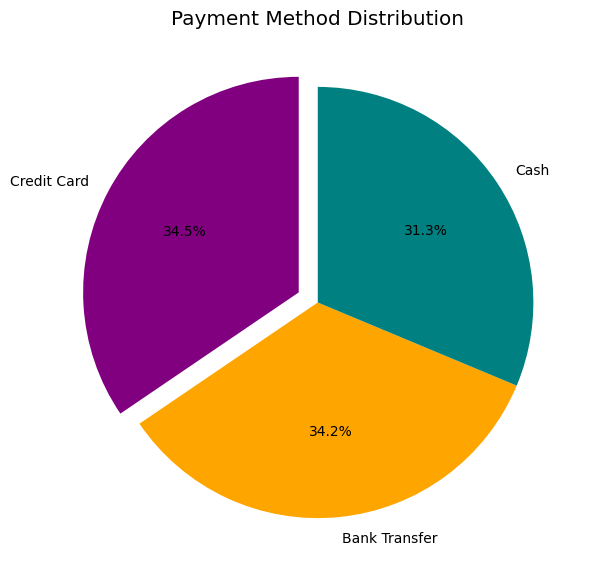

In [102]:
#colors = sns.color_palette("pastel")
colors=["purple","orange","teal"]
explode = (0.1, 0, 0)

payment_counts = df["Payment_Method"].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    payment_counts,
    labels=payment_counts.index,
    autopct="%1.1f%%",
    startangle=90,
    colors=colors,
    explode=explode
)

plt.title("Payment Method Distribution")

plt.savefig("images/payment_method_distribution.png", dpi=300, bbox_inches="tight")

plt.show()

## Observation
- Credit Card is the most frequently used payment method, accounting for 34.5% of all transactions.
- Cash is the least used payment method, accounting for 31.3% of the transactions.
- The usage of all payment methods is fairly balanced, with only a small difference in their usage percentages.
 
## Business Insight
Customers use all payment methods almost equally, indicating that the business should continue supporting all available payment options to ensure customer convenience.

## Visualization 6: Discount vs Sales Amount (Scatter Plot)

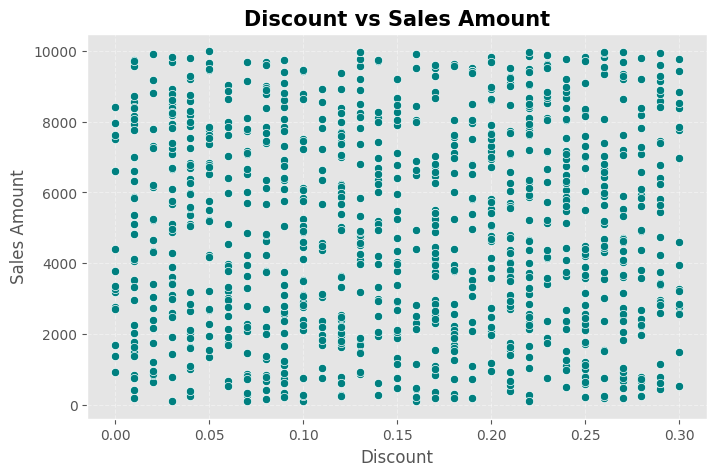

In [103]:
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Discount",
    y="Sales_Amount",
    data=df,
    color="teal"
)

plt.title("Discount vs Sales Amount", fontsize=15, fontweight="bold")
plt.xlabel("Discount")
plt.ylabel("Sales Amount")

plt.grid(True, linestyle="--", alpha=0.4)

plt.savefig("images/discount_vs_sales.png", dpi=300, bbox_inches="tight")

plt.show()

## Observation
- The scatter plot shows no clear correlation between Discount and Sales Amount.
- The data points are widely scattered across the graph, indicating that sales amounts vary at every discount level.
- Higher discounts do not consistently result in higher sales amounts.
- This suggests that discount alone does not have a strong influence on sales, and other factors may also affect the sales amount.

## Visualization 7: Sales Amount by Customer Type (Bar Chart)

In [118]:
customer_sales = df.groupby("Customer_Type")["Sales_Amount"].sum()

customer_sales

Customer_Type
New          2506258.30
Returning    2513006.93
Name: Sales_Amount, dtype: float64

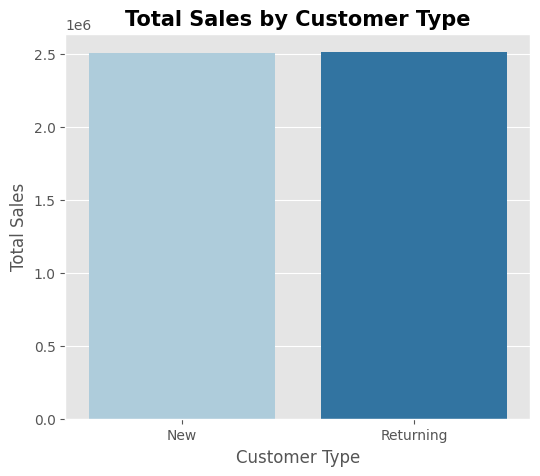

In [119]:
customer_sales = df.groupby("Customer_Type")["Sales_Amount"].sum()

plt.figure(figsize=(6,5))

sns.barplot(
    x=customer_sales.index,
    y=customer_sales.values,
    hue=customer_sales.index,
    palette="Paired"
)

plt.title("Total Sales by Customer Type", fontsize=15, fontweight="bold")
plt.xlabel("Customer Type")
plt.ylabel("Total Sales")

plt.savefig("images/customer_type_sales.png", dpi=300, bbox_inches="tight")

plt.show()

## Observation
- Returning customers generated the highest total sales.
- New customers generated slightly lower total sales.
- The difference between the two customer types is very small, indicating that both new and returning customers contribute almost equally to the overall sales revenue.

## Business Insight
Since both customer types contribute nearly the same amount of sales, the business should continue focusing on acquiring new customers while also retaining existing customers to maintain consistent revenue.

## Conclusion

This project used data visualization techniques to analyze sales data and identify important business insights. The analysis highlighted sales trends, regional performance, customer behavior, payment preferences, and product category performance. Overall, the visualizations transformed raw data into meaningful insights that can support better business decision-making.